# **Project Name**    - USA Regional Sales Analysis

## 🗂️ **Project Summary**  


This EDA notebook dives into Acme Co.’s 2014–2018 USA sales dataset through:

Data Profiling & Cleaning: Verified schema, handled missing budgets, and corrected data types.

Univariate & Bivariate Analysis: Explored distributions (revenue, margin, unit price), product/channel/region breakdowns, and customer segments.

Trend & Seasonality: Charted monthly and yearly sales patterns, highlighting recurring surges and dips.

Outlier Detection: Identified extreme transactions at both ends of the revenue and unit-price spectra.

Correlation & Segmentation: Assessed relationships between key metrics and clustered customers by revenue vs. profit margin.

## 💡 **Problem Statement**  

BBAS 2014–2018 sales data to identify key revenue and profit drivers across products, channels, and regions; uncover seasonal trends and outliers; and align performance against budgets. Use these insights to optimize pricing, promotions, and market expansion for sustainable growth and reduced concentration risk.

## 🎯 **Objective**

Deliver actionable insights from BBAS 2014–2018 sales data to:

- Identify top-performing products, channels, and regions driving revenue and profit  
- Uncover seasonal trends and anomalies for optimized planning  
- Spot pricing and margin risks from outlier transactions  
- Inform pricing, promotion, and market-expansion strategies  

These findings will guide the design of a Power BI dashboard to support strategic decision-making and sustainable growth.

# **📥 Setup & Configuration**

In [119]:
# 📘 1. IMPORT LIBRARIES

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure notebook display
%matplotlib inline
sns.set_style("whitegrid")    # clean seaborn style
plt.rcParams['figure.figsize'] = (10, 6)   # default fig size


# **🔄 Data Ingestion**

In [120]:
# 📂 2. LOAD DATA
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [121]:
# Path to your Excel workbook
file_path = '/content/drive/MyDrive/Retail_Analysis_Project/Regional Sales Dataset.xlsx'
# Read all sheets at once
sheets = pd.read_excel(file_path, sheet_name=None)

In [122]:
# Assign to named DataFrames
df_sales       = sheets['Sales Orders']
df_customers   = sheets['Customers']
df_products    = sheets['Products']
df_regions     = sheets['Regions']
df_state_reg   = sheets['State Regions']
df_budgets     = sheets['2017 Budgets']

In [123]:
# 🔍 2.1 QUICK SHAPE OVERVIEW
print(f"df_sales      shape: {df_sales.shape}      # Sales Orders")
print(f"df_customers  shape: {df_customers.shape}  # Customers")
print(f"df_products   shape: {df_products.shape}   # Products")
print(f"df_regions    shape: {df_regions.shape}    # Regions")
print(f"df_state_reg  shape: {df_state_reg.shape}  # State Regions")
print(f"df_budgets    shape: {df_budgets.shape}    # 2017 Budgets")

df_sales      shape: (64104, 12)      # Sales Orders
df_customers  shape: (175, 2)  # Customers
df_products   shape: (30, 2)   # Products
df_regions    shape: (994, 15)    # Regions
df_state_reg  shape: (49, 3)  # State Regions
df_budgets    shape: (30, 2)    # 2017 Budgets


In [124]:
# 🔍 3. DATA EXPLORATION / OVERVIEW

# 🔍 2.x — QUICK VIEW OF ALL RAW DATAFRAMES
# -----------------------------------------
# Print first few rows for each sheet

print("\n— df_sales head —")
display(df_sales.head(5))
print()

print("\n— df_customers head —")
display(df_customers.head(5))
print()

print("\n— df_products head —")
display(df_products.head(5))
print()

print("\n— df_regions head —")
display(df_regions.head(5))
print()

print("\n— df_state_reg head —")
display(df_state_reg.head(5))
print()

print("\n— df_budgets head —")
display(df_budgets.head(5))


— df_sales head —


,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270




— df_customers head —


,Customer Index,Customer Names
0,1,Geiss Company
1,2,Jaxbean Group
2,3,Ascend Ltd
3,4,Eire Corp
4,5,Blogtags Ltd




— df_products head —


...

,id,name,county,state_code,state,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,1,Auburn,Lee County,AL,Alabama,City,32.60986,-85.48078,334,62059,21767,38342,152375113,2646161,America/Chicago
1,2,Birmingham,Shelby County/Jefferson County,AL,Alabama,City,33.52744,-86.79905,205,212461,89972,31061,378353942,6591013,America/Chicago
2,3,Decatur,Limestone County/Morgan County,AL,Alabama,City,34.57332,-86.99214,256,55437,22294,41496,141006257,17594716,America/Chicago
3,4,Dothan,Dale County/Houston County/Henry County,AL,Alabama,City,31.23370,-85.40682,334,68567,25913,42426,232166237,835468,America/Chicago
4,5,Hoover,Shelby County/Jefferson County,AL,Alabama,City,33.37695,-86.80558,205,84848,32789,77146,122016784,2553332,America/Chicago




— df_state_reg head —


,Column1,Column2,Column3
0,State Code,State,Region
1,AL,Alabama,South
2,AR,Arkansas,South
3,AZ,Arizona,West
4,CA,California,West




— df_budgets head —


,Product Name,2017 Budgets
0,Product 1,3016489.209
1,Product 2,3050087.565
2,Product 3,2642352.432
3,Product 4,2885560.824
4,Product 5,3925424.542


In [125]:
# The first row of df_state_reg contains the real column names.
new_header        = df_state_reg.iloc[0]      # grab the first row
df_state_reg.columns = new_header             # set columns
df_state_reg       = df_state_reg[1:].reset_index(drop=True)  # drop header row and reset

In [126]:
df_sales.isnull().sum()

,0
OrderNumber,0
OrderDate,0
Customer Name Index,0
Channel,0
Currency Code,0
Warehouse Code,0
Delivery Region Index,0
Product Description Index,0
Order Quantity,0
Unit Price,0


In [127]:
# Checking duplicate values
len(df_sales) == len(df_sales.drop_duplicates())

True

In [128]:
df_sales.head()
df_sales['OrderDate'].min(), df_sales['OrderDate'].max()

(Timestamp('2014-01-01 00:00:00'), Timestamp('2018-02-28 00:00:00'))

###🧹 Data Cleaning & Wrangling

In [129]:
# 🔧 4. DATA WRANGLING & MERGING

# 4.1 Merge with Customers
df = df_sales.merge(
    df_customers,
    how='left',
    left_on='Customer Name Index',
    right_on='Customer Index'
)

In [130]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group


In [131]:
# 4.2 Merge with Products
df = df.merge(
    df_products,
    how='left',
    left_on='Product Description Index',
    right_on='Index'
)

In [132]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,Line Total,Total Unit Cost,Customer Index,Customer Names,Index,Product Name
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,14994.6,1824.343,126,Rhynoodle Ltd,27,Product 27
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,25868.7,1269.918,96,Thoughtmix Ltd,20,Product 20
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,5869.2,684.740,8,Amerisourc Corp,26,Product 26
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,16368.1,1028.852,42,Colgate-Pa Group,7,Product 7
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,18331.2,1260.270,73,Deseret Group,8,Product 8


In [133]:
# 4.3 Merge with Regions
df = df.merge(
    df_regions,
    how='left',
    left_on='Delivery Region Index',
    right_on='id'
)

In [134]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,type,latitude,longitude,area_code,population,households,median_income,land_area,water_area,time_zone
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,City,32.08354,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,City,39.61366,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,City,37.66243,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,City,39.16533,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,Town,41.77524,-72.52443,959,58007,24141,63158,70972793,720300,America/New York


In [135]:
# 4.4 Merge with State Regions
df = df.merge(
    df_state_reg[["State Code","Region"]],
    how='left',
    left_on='state_code',
    right_on='State Code'
)

In [136]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,GA,South
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast


In [137]:
# 4.5 Merge with Budgets
df = df.merge(
    df_budgets,
    how='left',
    on='Product Name'
)


In [138]:
df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,area_code,population,households,median_income,land_area,water_area,time_zone,State Code,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,912,145674,52798,36466,268318796,13908113,America/New York,GA,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,CA,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,959,58007,24141,63158,70972793,720300,America/New York,CT,Northeast,1085037.329


In [139]:
df.to_csv('file.csv')

In [140]:
# 4.6 Clean up redundant columns
cols_to_drop = [
    'Customer Index', 'Index', 'id', 'State Code',
    # add any auto-generated cols you don't need
]
df = df.drop(columns=cols_to_drop, errors='ignore')

df.head(5)

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,longitude,area_code,population,households,median_income,land_area,water_area,time_zone,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,-81.09983,912,145674,52798,36466,268318796,13908113,America/New York,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,-86.10665,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,-121.87468,925,79510,26020,124759,62489257,386195,America/Los Angeles,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,-86.52639,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,-72.52443,959,58007,24141,63158,70972793,720300,America/New York,Northeast,1085037.329


In [141]:
# Convert all column names to lowercase for consistency and easier access
df.columns = df.columns.str.lower()

# Display the updated list of column names
df.columns.values

array(['ordernumber', 'orderdate', 'customer name index', 'channel',
       'currency code', 'warehouse code', 'delivery region index',
       'product description index', 'order quantity', 'unit price',
       'line total', 'total unit cost', 'customer names', 'product name',
       'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households',
       'median_income', 'land_area', 'water_area', 'time_zone', 'region',
       '2017 budgets'], dtype=object)

In [142]:
# 4.x — DROP UNNECESSARY COLUMNS & RENAME FOR CLARITY (with Region)
# ------------------------------------------------------------------

# 1) List only the columns you want to KEEP, now including the broader 'region'
cols_to_keep = [
    'ordernumber',        # unique order ID
    'orderdate',          # date when the order was placed
    'customer names',     # customer who placed the order
    'channel',            # sales channel (e.g., Wholesale, Distributor)
    'product name',       # product purchased
    'order quantity',     # number of units ordered
    'unit price',         # price per unit
    'line total',         # revenue for this line item (qty × unit_price)
    'total unit cost',    # company’s cost for this line item
    'state_code',         # two-letter state code
    'state',              # full state name
    'region',             # broader U.S. region (e.g., South, West)
    'latitude',           # latitude of delivery city
    'longitude',          # longitude of delivery city
    '2017 budgets'        # budget target for this product in 2017
]

# Subset the DataFrame to only these columns
df = df[cols_to_keep]

In [143]:

# 2) Rename to more Pythonic / self-explanatory names, including region
df = df.rename(columns={
    'ordernumber'      : 'order_number',   # snake_case for consistency
    'orderdate'        : 'order_date',     # date of the order
    'customer names'   : 'customer_name',  # customer who placed it
    'product name'     : 'product_name',   # product sold
    'order quantity'   : 'quantity',       # units sold
    'unit price'       : 'unit_price',     # price per unit in USD
    'line total'       : 'revenue',        # revenue for the line item
    'total unit cost'  : 'cost',           # cost for the line item
    'state_code'       : 'state',          # two-letter state code
    'state'            : 'state_name',     # full state name
    'region'           : 'us_region',      # broader U.S. region
    'latitude'         : 'lat',            # latitude (float)
    'longitude'        : 'lon',            # longitude (float)
    '2017 budgets'     : 'budget'          # 2017 budget target (float)
})

# Display the cleaned DataFrame structure
df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,964940.231
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,2067108.120
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,5685138.270
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,889737.555
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,1085037.329


In [144]:
# Blank out budgets for non-2017 orders
df.loc[df['order_date'].dt.year != 2017, 'budget'] = pd.NA

# Inspect
df[['order_date','product_name','revenue','budget']].head(10)

,order_date,product_name,revenue,budget
0,2014-01-01,Product 27,14994.6,NaN
1,2014-01-01,Product 20,25868.7,NaN
2,2014-01-01,Product 26,5869.2,NaN
3,2014-01-01,Product 7,16368.1,NaN
4,2014-01-01,Product 8,18331.2,NaN
5,2014-01-01,Product 23,57412.3,NaN
6,2014-01-01,Product 1,20120.1,NaN
7,2014-01-01,Product 25,10452.0,NaN
8,2014-01-01,Product 13,19262.5,NaN
9,2014-01-01,Product 14,34974.0,NaN


In [145]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_number   64104 non-null  object        
 1   order_date     64104 non-null  datetime64[ns]
 2   customer_name  64104 non-null  object        
 3   channel        64104 non-null  object        
 4   product_name   64104 non-null  object        
 5   quantity       64104 non-null  int64         
 6   unit_price     64104 non-null  float64       
 7   revenue        64104 non-null  float64       
 8   cost           64104 non-null  float64       
 9   state          64104 non-null  object        
 10  state_name     64104 non-null  object        
 11  us_region      64104 non-null  object        
 12  lat            64104 non-null  float64       
 13  lon            64104 non-null  float64       
 14  budget         15263 non-null  float64       
dtypes: datetime64[ns](1

In [146]:
## Filter the dataset to include only records from 2017

df_2017 = df[df['order_date'].dt.year==2017]

In [147]:
df.isnull().sum()

,0
order_number,0
order_date,0
customer_name,0
channel,0
product_name,0
quantity,0
unit_price,0
revenue,0
cost,0
state,0


In [148]:
df_2017.head(5)

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget
46363,SO - 0002544,2017-01-01,NCS Group,Wholesale,Product 30,6,1239.5,7437.0,1028.785,NJ,New Jersey,Northeast,40.77955,-74.02375,1011609.684
46364,SO - 0006431,2017-01-01,Epic Group,Wholesale,Product 13,5,1829.1,9145.5,1207.206,CO,Colorado,West,39.06387,-108.55065,3720639.645
46365,SO - 0007491,2017-01-01,State Ltd,Wholesale,Product 15,9,2412.0,21708.0,1664.280,CA,California,West,33.96168,-118.35313,3299478.315
46366,SO - 0008741,2017-01-01,Fivebridge Ltd,Wholesale,Product 8,8,904.5,7236.0,750.735,IA,Iowa,Midwest,42.50056,-90.66457,1085037.329
46367,SO - 0009295,2017-01-01,Tagfeed Ltd,Wholesale,Product 2,12,1112.2,13346.4,811.906,FL,Florida,South,28.47689,-82.52546,3050087.565


###🛠 Feature Engineering

In [149]:
# 1. Calculate total cost for each line item
df['total_cost'] = df['quantity'] * df['cost']

In [150]:
# 2. Calculate profit as revenue minus total_cost
df['profit'] = df['revenue'] - df['total_cost']

In [151]:
# 3. Calculate profit margin as a percentage
df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

# 4. Extract full month name from order_date for labeling (e.g., 'January', 'February')
df['order_month_name'] = df['order_date'].dt.month_name()

# 5. Extract month number from order_date for correct sorting (1–12)
df['order_month_num'] = df['order_date'].dt.month

In [152]:
df.head(5)

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,state_name,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1


# **📊 Exploratory Analysis**

## 🔹 1. *Monthly Sales Trend Over Time*

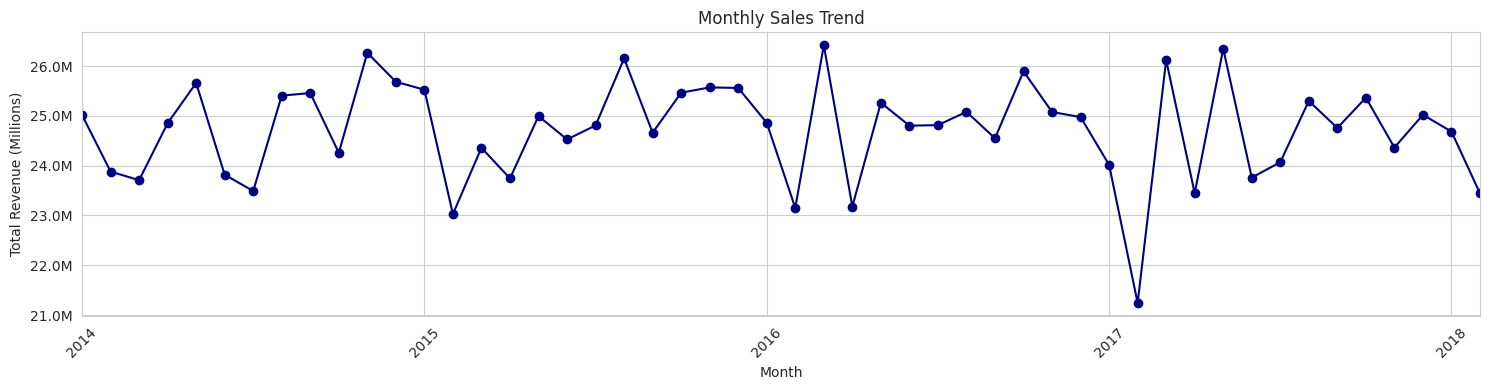

In [153]:
# Convert order_date to monthly period (e.g., 2022-01, 2022-02)
df['order_month'] = df['order_date'].dt.to_period('M')

# Calculate total revenue for each month
monthly_sales = df.groupby('order_month')['revenue'].sum()

# Set figure size for clarity
plt.figure(figsize=(15,4))

# Plot the monthly sales trend with circle markers and navy line
monthly_sales.plot(marker='o', color='navy')

# Scale y-axis values to millions for readability
from matplotlib.ticker import FuncFormatter
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

# Add title and axis labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (Millions)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to prevent clipping
plt.tight_layout()
plt.show()

### INSIGHTS ---
Sales consistently cycle between \$24 M and \$26 M, with clear peaks in late spring to early summer (May–June) and troughs each January.  

The overall trend remains stable year over year, reflecting a reliable seasonal demand pattern.  

However, the sharp revenue drop in early 2017 stands out as an outlier, warranting closer investigation into potential causes such as market disruptions or mistimed promotions.  

## 🔹 2. *Top 10 Products by Revenue (in Millions)*

/tmp/ipykernel_371/1186821662.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


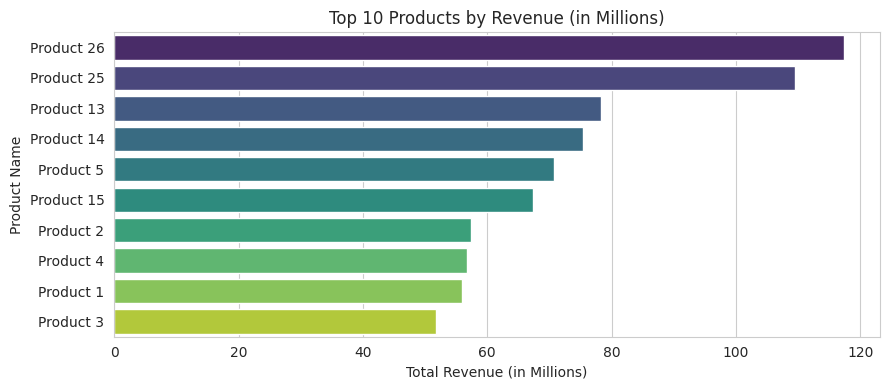

In [156]:
# Calculate total revenue for each product and convert values to millions
top_prod = df.groupby('product_name')['revenue'].sum() / 1_000_000

# Select the top 10 products by revenue
top_prod = top_prod.nlargest(10)

# Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart: x-axis as revenue in millions, y-axis as product names
sns.barplot(
    x=top_prod.values,    # X-axis: revenue values in millions
    y=top_prod.index,     # Y-axis: product names
    palette='viridis'     # Color palette for bars
)

# Add title and axis labels
plt.title('Top 10 Products by Revenue (in Millions)')  # Main title
plt.xlabel('Total Revenue (in Millions)')              # X-axis label
plt.ylabel('Product Name')                             # Y-axis label

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

### INSIGHTS ---
Products 26 and 25 pull away at \$118 M and \$110 M, with a sharp drop to \$78 M for Product 13 and a tight mid-pack at \$68–\$75 M.  

The bottom four cluster at \$52–\$57 M, highlighting similar constraints.  

Focus on growth pilots for the mid-tier and efficiency gains for the lower earners to drive significant lifts.  

##🔹3. Bottom 10 Products by Revenue (in Millions)

/tmp/ipykernel_371/1959075006.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


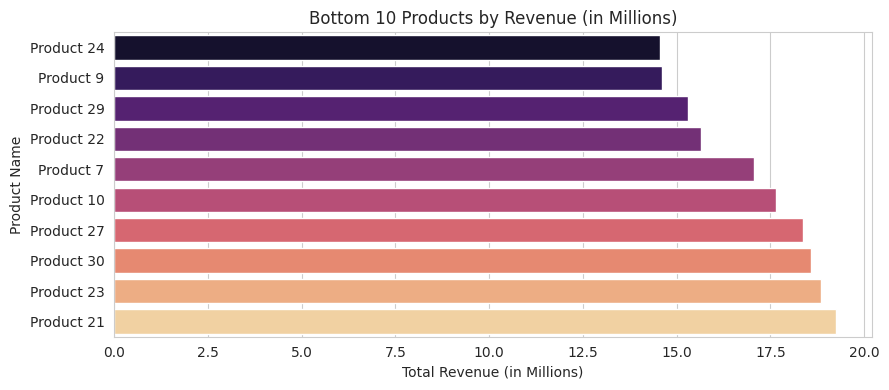

In [157]:
# Calculate total revenue for each product and convert values to millions
bottom_prod = df.groupby('product_name')['revenue'].sum() / 1_000_000

# Select the bottom 10 products by revenue
bottom_prod = bottom_prod.nsmallest(10)

# Set the figure size for clarity
plt.figure(figsize=(9, 4))

# Plot a horizontal bar chart
sns.barplot(
    x=bottom_prod.values,   # X-axis: revenue values in millions
    y=bottom_prod.index,    # Y-axis: product names
    palette='magma'         # Color palette
)

# Add title and axis labels
plt.title('Bottom 10 Products by Revenue (in Millions)')
plt.xlabel('Total Revenue (in Millions)')
plt.ylabel('Product Name')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

##INSIGHTS ---

Product 24 and Product 9 generate the lowest revenue, both near $14–$15 M, indicating the weakest demand within the portfolio.

Revenue gradually increases across the group, with Products 29 and 22 forming the lower-mid tier around $15–$16 M.

Products 7 and 10 move toward the upper range of this bottom segment at approximately $17–$18 M, while Products 27, 30, 23, and 21 approach $19 M, sitting just outside the low-revenue threshold.

The relatively tight revenue range (≈ $14 M – $19 M) suggests these products perform similarly and may be affected by comparable factors such as limited demand, weaker marketing exposure, or niche market positioning.

This segment represents an opportunity to investigate pricing strategy, product visibility, bundling opportunities, or inventory optimization to improve performance or decide whether some products should be deprioritized.

## 🔹 4. *Sales by Channel (Pie Chart)*

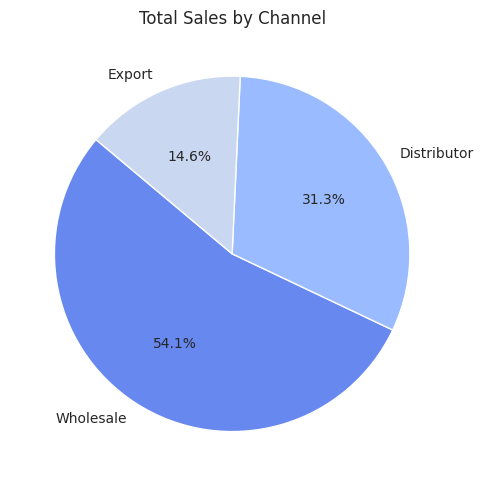

In [158]:
# Group revenue by sales channel and sort descending
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=False)

# Set figure size for the pie chart
plt.figure(figsize=(5, 5))

# Plot pie chart with percentage labels and a defined start angle
plt.pie(
    chan_sales.values,                   # Data: revenue values per channel
    labels=chan_sales.index,             # Labels: channel names
    autopct='%1.1f%%',                   # Display percentages with one decimal
    startangle=140,                      # Rotate chart so first slice starts at 140 degrees
    colors=sns.color_palette('coolwarm') # Color palette for slices
)

# Add title for context
plt.title('Total Sales by Channel')

# Adjust layout to ensure everything fits well
plt.tight_layout()

# Display the chart
plt.show()

### INSIGHTS ---
Wholesale accounts for 54 % of sales, with distributors at ~31 % and exports at ~15 %, underscoring reliance on domestic bulk channels.  

To diversify revenue and mitigate concentration risk, prioritize expanding export initiatives—through targeted overseas marketing and strategic partner relationships.  


## 🔹 5. *Average Order Value (AOV) Distribution*


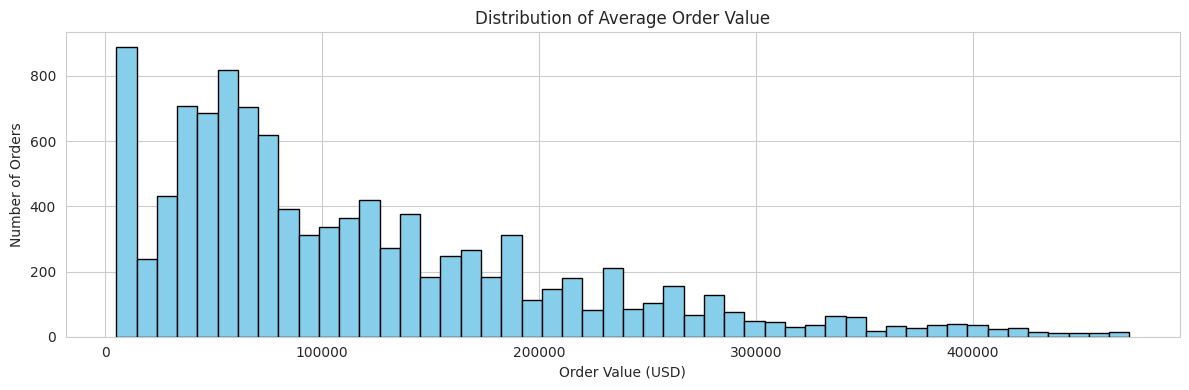

In [159]:
# Calculate the total revenue for each order to get the order value
aov = df.groupby('order_number')['revenue'].sum()

# Set the figure size for better visibility
plt.figure(figsize=(12, 4))

# Plot a histogram of order values
plt.hist(
    aov,               # Data: list of order values
    bins=50,           # Number of bins to group order values
    color='skyblue',   # Fill color of the bars
    edgecolor='black'  # Outline color of the bars
)

# Add title and axis labels for context
plt.title('Distribution of Average Order Value')
plt.xlabel('Order Value (USD)')
plt.ylabel('Number of Orders')

# Adjust layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

### INSIGHTS ---
The order‐value distribution is heavily right‐skewed, with most orders clustering between \$20 K and \$120 K and a pronounced mode around \$50 K–\$60 K.  

A long tail of high-value transactions extends up toward \$400 K–\$500 K, but these large orders represent only a small share of total volume.  

In [160]:
df.groupby('order_month_name')['budget'].count()

,budget
order_month_name,
April,1220
August,1269
December,1313
February,1134
January,1234
July,1292
June,1228
March,1339
May,1348


In [161]:
df['budget'].describe()

,budget
count,1.526300e+04
mean,2.989305e+06
std,1.557271e+06
min,5.944716e+05
25%,1.672229e+06
50%,3.016489e+06
75%,3.925425e+06
max,5.685138e+06


In [162]:
df[['revenue','budget']].head(10)

,revenue,budget
0,14994.6,NaN
1,25868.7,NaN
2,5869.2,NaN
3,16368.1,NaN
4,18331.2,NaN
5,57412.3,NaN
6,20120.1,NaN
7,10452.0,NaN
8,19262.5,NaN
9,34974.0,NaN


In [163]:
df[['revenue','budget']].describe()

,revenue,budget
count,64104.000000,1.526300e+04
mean,19280.682937,2.989305e+06
std,15429.602766,1.557271e+06
min,837.500000,5.944716e+05
25%,8019.900000,1.672229e+06
50%,14023.100000,3.016489e+06
75%,27416.400000,3.925425e+06
max,78711.600000,5.685138e+06


In [164]:
# Export Final DataFrame to CSV
df.to_csv('Sales_data(EDA Exported).csv', index=False)

In [165]:
df['order_date'].min(), df['order_date'].max()

(Timestamp('2014-01-01 00:00:00'), Timestamp('2018-02-28 00:00:00'))

In [166]:
for col in df.columns:
    print(col)

order_number
order_date
customer_name
channel
product_name
quantity
unit_price
revenue
cost
state
state_name
us_region
lat
lon
budget
total_cost
profit
profit_margin_pct
order_month_name
order_month_num
order_month


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_number       64104 non-null  object        
 1   order_date         64104 non-null  datetime64[ns]
 2   customer_name      64104 non-null  object        
 3   channel            64104 non-null  object        
 4   product_name       64104 non-null  object        
 5   quantity           64104 non-null  int64         
 6   unit_price         64104 non-null  float64       
 7   revenue            64104 non-null  float64       
 8   cost               64104 non-null  float64       
 9   state              64104 non-null  object        
 10  state_name         64104 non-null  object        
 11  us_region          64104 non-null  object        
 12  lat                64104 non-null  float64       
 13  lon                64104 non-null  float64       
 14  budget

In [168]:
df.columns

Index(['order_number', 'order_date', 'customer_name', 'channel',
       'product_name', 'quantity', 'unit_price', 'revenue', 'cost', 'state',
       'state_name', 'us_region', 'lat', 'lon', 'budget', 'total_cost',
       'profit', 'profit_margin_pct', 'order_month_name', 'order_month_num',
       'order_month'],
      dtype='object')

In [169]:
df.head()

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,...,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num,order_month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1,2014-01
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1,2014-01
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1,2014-01
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,...,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0,January,1,2014-01
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,...,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0,January,1,2014-01


##Dimension table

In [170]:
dim_product = df[['product_name']].drop_duplicates().reset_index(drop=True)

dim_product['product_id'] = dim_product.index + 1

In [171]:
dim_product = dim_product[['product_id','product_name']]

In [172]:
dim_product.head()

,product_id,product_name
0,1,Product 27
1,2,Product 20
2,3,Product 26
3,4,Product 7
4,5,Product 8


In [173]:
dim_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    30 non-null     int64 
 1   product_name  30 non-null     object
dtypes: int64(1), object(1)
memory usage: 612.0+ bytes


In [174]:
dim_product.isnull().sum()

,0
product_id,0
product_name,0


In [175]:
dim_product.duplicated(subset=['product_name']).sum()

np.int64(0)

In [176]:
dim_product.info()
dim_product.isnull().sum()
dim_product.duplicated(subset=['product_name']).sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    30 non-null     int64 
 1   product_name  30 non-null     object
dtypes: int64(1), object(1)
memory usage: 612.0+ bytes


np.int64(0)

In [177]:
dim_customer = df[['customer_name']].drop_duplicates().reset_index(drop=True)

dim_customer['customer_id'] = dim_customer.index + 1

In [178]:
dim_customer = dim_customer[['customer_id','customer_name']]

In [179]:
dim_customer.head()

,customer_id,customer_name
0,1,Rhynoodle Ltd
1,2,Thoughtmix Ltd
2,3,Amerisourc Corp
3,4,Colgate-Pa Group
4,5,Deseret Group


In [180]:
dim_channel = df[['channel']].drop_duplicates().reset_index(drop=True)

dim_channel['channel_id'] = dim_channel.index + 1

In [181]:
dim_channel = dim_channel[['channel_id','channel']]

In [182]:
dim_channel.head()

,channel_id,channel
0,1,Wholesale
1,2,Distributor
2,3,Export


In [187]:
dim_location = df[['state','state_name','us_region','lat','lon']] \
    .drop_duplicates(subset=['state']) \
    .reset_index(drop=True)

dim_location['location_id'] = dim_location.index + 1

dim_location = dim_location[['location_id','state','state_name','us_region','lat','lon']]

In [188]:
dim_location.head()

,location_id,state,state_name,us_region,lat,lon
0,1,GA,Georgia,South,32.08354,-81.09983
1,2,IN,Indiana,Midwest,39.61366,-86.10665
2,3,CA,California,West,37.66243,-121.87468
3,4,CT,Connecticut,Northeast,41.77524,-72.52443
4,5,MN,Minnesota,Midwest,44.91330,-93.50329


In [192]:
df['year'] = df['order_date'].dt.year

In [193]:
dim_date = df[['order_date','order_month_name','order_month_num','year']] \
    .drop_duplicates() \
    .reset_index(drop=True)

In [194]:
dim_date.head()

,order_date,order_month_name,order_month_num,year
0,2014-01-01,January,1,2014
1,2014-01-02,January,1,2014
2,2014-01-03,January,1,2014
3,2014-01-04,January,1,2014
4,2014-01-05,January,1,2014


## **Fact** **Table**

In [195]:
fact_sales = df[[
    'order_number',
    'order_date',
    'product_name',
    'customer_name',
    'channel',
    'state',
    'quantity',
    'unit_price',
    'revenue',
    'cost',
    'total_cost',
    'profit',
    'profit_margin_pct'
]]

In [196]:
fact_sales.head()

,order_number,order_date,product_name,customer_name,channel,state,quantity,unit_price,revenue,cost,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Product 27,Rhynoodle Ltd,Wholesale,GA,6,2499.1,14994.6,1824.343,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Product 20,Thoughtmix Ltd,Distributor,IN,11,2351.7,25868.7,1269.918,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Product 26,Amerisourc Corp,Wholesale,CA,6,978.2,5869.2,684.740,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Product 7,Colgate-Pa Group,Export,IN,7,2338.3,16368.1,1028.852,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Product 8,Deseret Group,Wholesale,CT,8,2291.4,18331.2,1260.270,10082.160,8249.040,45.0


In [197]:
fact_sales = fact_sales.merge(
    dim_product,
    on='product_name',
    how='left'
)

In [198]:
fact_sales.head()

,order_number,order_date,product_name,customer_name,channel,state,quantity,unit_price,revenue,cost,total_cost,profit,profit_margin_pct,product_id
0,SO - 000225,2014-01-01,Product 27,Rhynoodle Ltd,Wholesale,GA,6,2499.1,14994.6,1824.343,10946.058,4048.542,27.0,1
1,SO - 0003378,2014-01-01,Product 20,Thoughtmix Ltd,Distributor,IN,11,2351.7,25868.7,1269.918,13969.098,11899.602,46.0,2
2,SO - 0005126,2014-01-01,Product 26,Amerisourc Corp,Wholesale,CA,6,978.2,5869.2,684.740,4108.440,1760.760,30.0,3
3,SO - 0005614,2014-01-01,Product 7,Colgate-Pa Group,Export,IN,7,2338.3,16368.1,1028.852,7201.964,9166.136,56.0,4
4,SO - 0005781,2014-01-01,Product 8,Deseret Group,Wholesale,CT,8,2291.4,18331.2,1260.270,10082.160,8249.040,45.0,5


In [199]:
df['revenue'].sum()

np.float64(1235968899.0)

In [200]:
fact_sales['revenue'].sum()

np.float64(1235968899.0)

In [201]:
fact_sales = fact_sales.merge(
    dim_customer,
    on='customer_name',
    how='left'
)

In [202]:
fact_sales.head()

,order_number,order_date,product_name,customer_name,channel,state,quantity,unit_price,revenue,cost,total_cost,profit,profit_margin_pct,product_id,customer_id
0,SO - 000225,2014-01-01,Product 27,Rhynoodle Ltd,Wholesale,GA,6,2499.1,14994.6,1824.343,10946.058,4048.542,27.0,1,1
1,SO - 0003378,2014-01-01,Product 20,Thoughtmix Ltd,Distributor,IN,11,2351.7,25868.7,1269.918,13969.098,11899.602,46.0,2,2
2,SO - 0005126,2014-01-01,Product 26,Amerisourc Corp,Wholesale,CA,6,978.2,5869.2,684.740,4108.440,1760.760,30.0,3,3
3,SO - 0005614,2014-01-01,Product 7,Colgate-Pa Group,Export,IN,7,2338.3,16368.1,1028.852,7201.964,9166.136,56.0,4,4
4,SO - 0005781,2014-01-01,Product 8,Deseret Group,Wholesale,CT,8,2291.4,18331.2,1260.270,10082.160,8249.040,45.0,5,5


In [203]:
fact_sales['revenue'].sum()

np.float64(1235968899.0)

In [204]:
fact_sales = fact_sales.merge(
    dim_channel,
    on='channel',
    how='left'
)

In [205]:
fact_sales.head()

,order_number,order_date,product_name,customer_name,channel,state,quantity,unit_price,revenue,cost,total_cost,profit,profit_margin_pct,product_id,customer_id,channel_id
0,SO - 000225,2014-01-01,Product 27,Rhynoodle Ltd,Wholesale,GA,6,2499.1,14994.6,1824.343,10946.058,4048.542,27.0,1,1,1
1,SO - 0003378,2014-01-01,Product 20,Thoughtmix Ltd,Distributor,IN,11,2351.7,25868.7,1269.918,13969.098,11899.602,46.0,2,2,2
2,SO - 0005126,2014-01-01,Product 26,Amerisourc Corp,Wholesale,CA,6,978.2,5869.2,684.740,4108.440,1760.760,30.0,3,3,1
3,SO - 0005614,2014-01-01,Product 7,Colgate-Pa Group,Export,IN,7,2338.3,16368.1,1028.852,7201.964,9166.136,56.0,4,4,3
4,SO - 0005781,2014-01-01,Product 8,Deseret Group,Wholesale,CT,8,2291.4,18331.2,1260.270,10082.160,8249.040,45.0,5,5,1


In [206]:
fact_sales['revenue'].sum()

np.float64(1235968899.0)

In [210]:
fact_sales = fact_sales.merge(
    dim_location[['location_id','state']],
    on='state',
    how='left'
)

In [211]:
fact_sales.head()

,order_number,order_date,product_name,customer_name,channel,state,quantity,unit_price,revenue,cost,total_cost,profit,profit_margin_pct,product_id,customer_id,channel_id,location_id
0,SO - 000225,2014-01-01,Product 27,Rhynoodle Ltd,Wholesale,GA,6,2499.1,14994.6,1824.343,10946.058,4048.542,27.0,1,1,1,1
1,SO - 0003378,2014-01-01,Product 20,Thoughtmix Ltd,Distributor,IN,11,2351.7,25868.7,1269.918,13969.098,11899.602,46.0,2,2,2,2
2,SO - 0005126,2014-01-01,Product 26,Amerisourc Corp,Wholesale,CA,6,978.2,5869.2,684.740,4108.440,1760.760,30.0,3,3,1,3
3,SO - 0005614,2014-01-01,Product 7,Colgate-Pa Group,Export,IN,7,2338.3,16368.1,1028.852,7201.964,9166.136,56.0,4,4,3,2
4,SO - 0005781,2014-01-01,Product 8,Deseret Group,Wholesale,CT,8,2291.4,18331.2,1260.270,10082.160,8249.040,45.0,5,5,1,4


In [212]:
fact_sales['revenue'].sum()

np.float64(1235968899.0)

In [213]:
fact_sales = fact_sales[[
    'order_number',
    'order_date',
    'product_id',
    'customer_id',
    'channel_id',
    'location_id',
    'quantity',
    'unit_price',
    'revenue',
    'cost',
    'total_cost',
    'profit',
    'profit_margin_pct'
]]

In [214]:
df['profit'].sum()

np.float64(461772559.9200001)

In [215]:
fact_sales['profit'].sum()

np.float64(461772559.9200001)

In [216]:
df['profit'].sum() / df['revenue'].sum()

np.float64(0.37361179580943493)

In [217]:
fact_sales['profit'].sum() / fact_sales['revenue'].sum()

np.float64(0.37361179580943493)

In [218]:
df['order_number'].nunique()

10684

In [219]:
fact_sales['order_number'].nunique()

10684

In [220]:
total_orders = fact_sales['order_number'].nunique()
total_orders

10684

In [221]:
revenue_per_order = fact_sales['revenue'].sum() / fact_sales['order_number'].nunique()
revenue_per_order

np.float64(115684.09762261325)

In [222]:
fact_sales.to_csv('fact_sales.csv', index=False)

dim_product.to_csv('dim_product.csv', index=False)

dim_customer.to_csv('dim_customer.csv', index=False)

dim_channel.to_csv('dim_channel.csv', index=False)

dim_location.to_csv('dim_location.csv', index=False)

dim_date.to_csv('dim_date.csv', index=False)

# 💡 **Final Business Summary**

- Revenue shows stable seasonal patterns
- Top products contribute majority of revenue
- Bottom products cluster closely — optimization opportunity
- Wholesale dominates channel contribution
- Regional performance is consistent across regions

# 💡 **Key Insights**  



- **Monthly Revenue Cycle:**  
  Revenue stays stable between ≈\$23M–\$26.5M across 2014–2017, with no consistent seasonal spikes. Sharpest drop (≈\$21.2M) occurs in early 2017, indicating a possible one-time disruption.

- **Channel Mix:**  
  Wholesale: 54%. Distributors: 31%. Exports: 15% — opportunity to scale international presence.

- **Top Products (Revenue):**  
  Product 26: \$118M; Product 25: \$110M; Product 13: \$78M. Mid-tier: \$68–75M; bottom performers: \$52–57M.

- **Profit Margins:**  
  Profit margins range broadly from ≈18% to ≈60%, with no strong correlation to unit price. Dense horizontal bands suggest standardized pricing strategies across tiers.

- **Seasonal Volume:**  
  No strong monthly pattern, but slight volume uptick appears around May–June. Early 2017 dip (≈\$21.2M) may require investigation.

- **Regional Performance:**  
  California leads: ≈\$230M Revenue & 7500+ orders. Illinois/Florida/Texas: ≈\$85M–$110M & ≈3500–4500 orders. NY/Indiana: ≈\$54M & 2000+ orders.



# 💡 **Recommendations**  

1. **Outlier Strategy:** Exclude or formalize bulk-order and promotional SKUs when calculating averages.  
2. **Margin Uplift:** Apply top-product pricing levers to mid/low tiers; cut costs on underperformers.  
3. **Export Growth:** Invest in targeted overseas marketing and distributor partnerships.  
4. **Seasonal Planning:** Shift spend toward January trough and May–June peak; investigate the 2017 anomaly.  
5. **Dashboard Prep:** Build aggregated tables for time series, channel mix, and product performance for Power BI.  